## Overview

CNN-GRU Setup for prediction out of 2D timeseries data

finding out of impact of training on "wrong" year of the saison


Colab version of local, loading data from existing dataloaders

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 3.6.

In [ ]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

import xarray as xr
from my_dataloader_module import TimeseriesDatasetPipeline, TimeseriesPyTorchDataset

rSeed=42

SavePlots = False

## Loading Data

In [23]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [27]:
!cd drive/MyDrive/small_grid && ls

dataloaders			       grid-timeseries_sel_vars_2016.grib.nc
grib_to_pd_dataset.ipynb	       grid-timeseries_sel_vars_2017.grib.nc
grid-timeseries_sel_vars_1940.grib.nc  grid-timeseries_sel_vars_2018.grib.nc
grid-timeseries_sel_vars_1950.grib.nc  grid-timeseries_sel_vars_2019.grib.nc
grid-timeseries_sel_vars_1960.grib.nc  grid-timeseries_sel_vars_2020.grib.nc
grid-timeseries_sel_vars_1970.grib.nc  grid-timeseries_sel_vars_2021.grib.nc
grid-timeseries_sel_vars_1980.grib.nc  grid-timeseries_sel_vars_2022.grib.nc
grid-timeseries_sel_vars_1990.grib.nc  grid-timeseries_sel_vars_2023.grib.nc
grid-timeseries_sel_vars_2000.grib.nc  grid-timeseries_sel_vars_2024.grib.nc
grid-timeseries_sel_vars_2010.grib.nc  grid-timeseries_sel_vars_2025.grib.nc
grid-timeseries_sel_vars_2015.grib.nc


In [31]:
folder='drive/MyDrive/small_grid'
filelist=!cd {folder} && ls



print(filelist)
print(len(filelist))

['dataloaders\t\t\t       grid-timeseries_sel_vars_2016.grib.nc', 'grib_to_pd_dataset.ipynb\t       grid-timeseries_sel_vars_2017.grib.nc', 'grid-timeseries_sel_vars_1940.grib.nc  grid-timeseries_sel_vars_2018.grib.nc', 'grid-timeseries_sel_vars_1950.grib.nc  grid-timeseries_sel_vars_2019.grib.nc', 'grid-timeseries_sel_vars_1960.grib.nc  grid-timeseries_sel_vars_2020.grib.nc', 'grid-timeseries_sel_vars_1970.grib.nc  grid-timeseries_sel_vars_2021.grib.nc', 'grid-timeseries_sel_vars_1980.grib.nc  grid-timeseries_sel_vars_2022.grib.nc', 'grid-timeseries_sel_vars_1990.grib.nc  grid-timeseries_sel_vars_2023.grib.nc', 'grid-timeseries_sel_vars_2000.grib.nc  grid-timeseries_sel_vars_2024.grib.nc', 'grid-timeseries_sel_vars_2010.grib.nc  grid-timeseries_sel_vars_2025.grib.nc', 'grid-timeseries_sel_vars_2015.grib.nc']
11


In [ ]:
#year="2020"
#ending = ".grib.nc"
#filename="../../../datasets/small_grid/grid-timeseries_sel_vars_"+year+ending

filelist=!ls



#only select recent years until 2015
years = [str(year) for year in range(2015, 2025)]
print(years)

#filter the filelist to only include files for the selected years
filelist = [filename for filename in filelist if any(year in filename for year in years)]
print(filelist)

# Open the NetCDF files using xarray
ds={}
ds[year]= xr.open_dataset(filename)
ds1=ds[year]
ds["2021"]=ds1
ds.keys()

#combining the dict datasets into one xarray dataset
ds_combined = xr.concat([ds[year] for year in ds.keys()], dim='time')
ds_combined

ds_spring = ds_combined.sel(time=ds_combined['time.season'] == 'MAM')
ds_summer = ds_combined.sel(time=ds_combined['time.season'] == 'JJA')
ds_autumn = ds_combined.sel(time=ds_combined['time.season'] == 'SON')
ds_winter = ds_combined.sel(time=ds_combined['time.season'] == 'DJF')
df=ds1.sel(time=ds1['time.month'] == 3)#march
print(df)



ds=ds1.sel(time=ds1['time.season'] == 'MAM')

ds_test=ds_summer
ds_test

['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


NameError: name 'filename' is not defined

In [189]:
#if dataloaders are not already created, create them and save for later use
folder_path = "../../../datasets/small_grid/dataloaders/"

if not (os.path.exists(folder_path + "dataloader_train.pt") and os.path.exists(folder_path + "dataloader_val.pt") and os.path.exists(folder_path + "dataloader_test.pt")):
    print("Dataloaders not found. Creating and saving dataloaders...")
    batch_size=64
    lag_selection=[0, 24, 48, 60, 66, 69, 71]
    validate_ratio=0.20

    pipeline= TimeseriesDatasetPipeline(ds, lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
    dataloader_train,dataloader_val=pipeline.to_scaled_pytorch_train_test_dataloaders(batch_size=batch_size, test_size=validate_ratio, random_state=rSeed)

    pipeline_test = TimeseriesDatasetPipeline(ds_test, lag_selection=lag_selection, forecast_horizon=1, forecast_var=5)
    dataloader_test = pipeline_test.to_scaled_pytorch_dataloader(batch_size=batch_size, shuffle=False)

    #saving dataloaders for later use
    torch.save(dataloader_train, folder_path + "dataloader_train.pt")
    torch.save(dataloader_val, folder_path + "dataloader_val.pt")
    torch.save(dataloader_test, folder_path + "dataloader_test.pt")
    print("dataloaders saved successfully.")

else:
    print("Dataloaders already exist. Loading from disk...")
    dataloader_train = torch.load(folder_path + "dataloader_train.pt", weights_only=False)
    dataloader_val = torch.load(folder_path + "dataloader_val.pt", weights_only=False)
    dataloader_test = torch.load(folder_path + "dataloader_test.pt", weights_only=False)
    print("Dataloaders loaded successfully.")

Dataloaders already exist. Loading from disk...
Dataloaders loaded successfully.


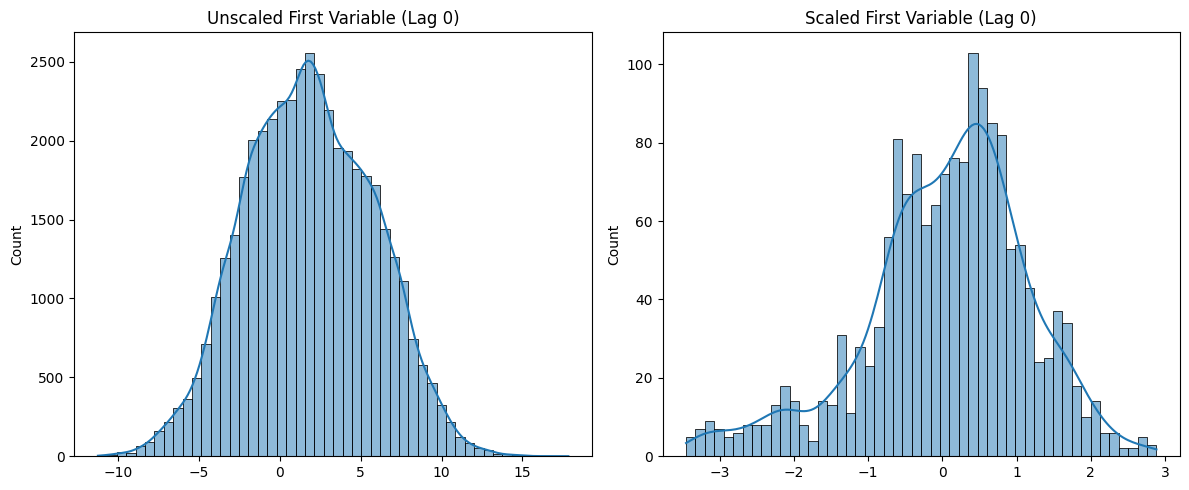

In [190]:
#Histogram of first variable scaled and unscaled for training dataloader
X_train, _ = next(iter(dataloader_train))
X_train_unscaled = pipeline.data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train_unscaled[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Unscaled First Variable (Lag 0)")
plt.subplot(1, 2, 2)
sns.histplot(X_train[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Scaled First Variable (Lag 0)")
plt.tight_layout()

In [191]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


hidden_size=16

class CNN_GRU(nn.Module):
    def __init__(self,in_channels=7,hidden_size=16,lat_size=5,lon_size=5):
        super().__init__()

        #compressing space
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.conv1 = double_conv(in_channels, 16)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = double_conv(16, 32)

        #compressing time
        self.gru = nn.GRU(input_size=32,hidden_size=32*25, num_layers=1,dropout=0.2,batch_first=True)
        
        #expanding space
        self.deconv1 = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.deconv2 = nn.ConvTranspose2d(16, 1, kernel_size=3, padding=1)


    def forward(self, x):
        #print("starting forward:",x.shape)
        x_gru=[]
        #recognize patterns of the spatial data with CNN
        for time in range(x.shape[1]):
            #print(time)
            cnn_in=x[:, time, :, :]
            #print("time,cnn_in.shape:",time,cnn_in.shape)
            cnn_in=self.conv1(cnn_in)
            #print("after conv1:",cnn_in.shape)
            cnn_in = self.maxpool(cnn_in)
            #print("after maxpool:",cnn_in.shape)
            cnn_in = self.conv2(cnn_in)
            #print("after conv2:",cnn_in.shape)
            cnn_in = self.maxpool(cnn_in)
            #print("after maxpool:",cnn_in.shape)
            cnn_in = cnn_in.view(cnn_in.size(0), -1)  # Flatten for GRU input
            #print("after flatten:",cnn_in.shape)
            x_gru.append(cnn_in)
        x_gru = torch.stack(x_gru, dim=1)
        #print("shaped for GRU:",x_gru.shape)#(batch, time, convoluted features with space)

        #decoding the temporal patterns with GRU
        x,_ = self.gru(x_gru)#x:(batch, time, hidden_size)
        x = x[:,-1,:].view(x.shape[0],32,5,5)##(batch, last hidden_size,lat_size,lon_size)
        #print("after GRU:",x.shape)
        x=self.deconv1(x)
        #print("after deconv1:",x.shape)
        x=self.deconv2(x)
        #print("after deconv2:",x.shape)
        return x# 


cnn_gru_model=CNN_GRU().to(device)
print(cnn_gru_model)

# Loss function and optimizer
loss_fcn = nn.MSELoss()
optimizer_cnn_gru = AdamW(cnn_gru_model.parameters(), lr=1e-3, weight_decay=1e-4)

Using cpu device
CNN_GRU(
  (conv1): Sequential(
    (0): Conv2d(7, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (gru): GRU(32, 800, batch_first=True, dropout=0.2)
  (deconv1): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


/home/peter/anaconda3/envs/appmlenv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [192]:
def train(dataloader, model, loss_fn, optimizer,device):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        #print(X.shape, y.shape)
        X, y = X.to(device), y.to(device)
        #print(X.shape, y.shape)
        pred = model(X)#.squeeze()
        #print(pred)#.shape)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Train Loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    return loss.item()



def test(dataloader, model, loss_fn,device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            test_loss += loss_fn(predictions, y).item()

            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    test_loss /= num_batches
    y_pred = np.concatenate(all_predictions)#[:,:,0]
    y_true = np.concatenate(all_targets)#[:,:,0]
    #print(f"y_true shape: {y_true.shape}, y_pred shape: {y_pred.shape}")

    # Flatten everything to 2D: (samples, features)
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)

    #mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    #rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true_flat, y_pred_flat)
    print(f"Test Error:\n R2: {r2:>8f}, Avg loss: {test_loss:>8f} \n")
    return test_loss

In [193]:
epochs = 2

train_losses=[]
val_losses=[]
test_losses=[]

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_losses.append(train(dataloader_train, cnn_gru_model, loss_fcn, optimizer_cnn_gru,device))
    val_losses.append(test(dataloader_val, cnn_gru_model, loss_fcn,device)) 
    test_losses.append(test(dataloader_test, cnn_gru_model, loss_fcn,device)) 

train_losses=np.array(train_losses)
val_losses=np.array(val_losses)
test_losses=np.array(test_losses)

print("Done!")


Epoch 1
-------------------------------
Train Loss: 1.163391  [   64/ 1707]
Test Error:
 R2: 0.361266, Avg loss: 0.675111 

Test Error:
 R2: 0.076697, Avg loss: 0.906340 

Epoch 2
-------------------------------
Train Loss: 0.602146  [   64/ 1707]
Test Error:
 R2: 0.642724, Avg loss: 0.376528 

Test Error:
 R2: 0.464691, Avg loss: 0.538265 

Epoch 3
-------------------------------
Train Loss: 0.386728  [   64/ 1707]
Test Error:
 R2: 0.697260, Avg loss: 0.319702 

Test Error:
 R2: 0.502293, Avg loss: 0.492251 

Done!


## Optimizing - Hyperparametertuning

## saving trained model

In [ ]:
season="summer"
model_name = f"cnn_gru_{season}"

os.makedirs("models", exist_ok=True)
save_path = f"models/{model_name}.pth"

torch.save({
    "model_state_dict": cnn_gru_model.state_dict(),
    "optimizer_state_dict": optimizer_cnn_gru.state_dict(),
    "lag_selection": lag_selection,
    "epoch": epochs
}, save_path)

print(f"Saved model to {save_path}")

Saved model to models/cnn_gru_summer.pth


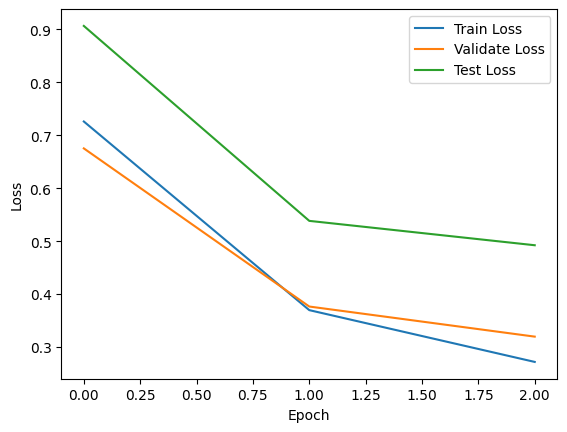

In [ ]:
# plot for performance for each epoch - loss vs epoch

fig, ax = plt.subplots()
ax.plot(train_losses, label='Train Loss')
ax.plot(val_losses, label='Validate Loss')
ax.plot(test_losses, label='Test Loss')
ax.set_xlabel('Epoch')  
ax.set_ylabel('MSE Loss')
ax.legend()
plt.show()



In [ ]:
# save train and test losses to csv
df = pd.DataFrame({'Train Loss': train_losses, 'Validate Loss': val_losses, 'Test Loss': test_losses})
df.to_csv(f'losses_{model_name}.csv', index=False)

## retrieve saved model

In [ ]:
# Load the saved model
checkpoint = torch.load(save_path)

# Create a new model instance
cnn_gru_model_loaded = CNN_GRU().to(device)

# Load the saved state
cnn_gru_model_loaded.load_state_dict(checkpoint["model_state_dict"])

# Optionally load other components
loaded_scaler_set = checkpoint["scaler_set"]
loaded_lag_selection = checkpoint["lag_selection"]
loaded_epoch = checkpoint["epoch"]

print(f"Model loaded from {save_path}")
print(f"Training stopped at epoch: {loaded_epoch}")
print(f"Lag selection: {loaded_lag_selection}")

# Set model to evaluation mode for inference
cnn_gru_model_loaded.eval()